### 01 — Exploratory Data Analysis (EDA)
**Phase:** 1. Data Exploration  
**Owner:** Taline  

This notebook covers:
1. Loading the data
2. Basic inspection
3. Target variable analysis (class balance)
4. Missing values
5. Feature-by-feature analysis
6. Timestamp analysis
7. Correlation & key insights
8. Save merged/cleaned data for next phase


## 1. Imports & Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Relative paths
DATA_DIR    = os.path.join('..', 'data')
OUTPUT_DIR  = os.path.join('..', 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_PATH  = os.path.join(DATA_DIR, 'train.csv')
TEST_PATH   = os.path.join(DATA_DIR, 'test.csv')

print("Paths ready.")
print(f"  Train : {TRAIN_PATH}")
print(f"  Test  : {TEST_PATH}")
print(f"  Output: {OUTPUT_DIR}")


Paths ready.
  Train : ..\data\train.csv
  Test  : ..\data\test.csv
  Output: ..\outputs


## 2. Load Data

In [2]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f"Train shape : {train.shape}  ({train.shape[0]:,} rows, {train.shape[1]} columns)")
print(f"Test shape  : {test.shape}  ({test.shape[0]:,} rows, {test.shape[1]} columns)")


Train shape : (297236, 18)  (297,236 rows, 18 columns)
Test shape  : (99639, 17)  (99,639 rows, 17 columns)


In [3]:
# Rename columns from anonymized codes to descriptive names
rename_map = {
    'f2' : 'session_id',
    'f3' : 'session_start',
    'f4' : 'session_end',
    'f5' : 'last_activity',
    'f6' : 'timezone',
    'f7' : 'action_type',
    'f8' : 'promos_declined',
    'f9' : 'customer_type',
    'f10': 'items_in_cart',
    'f11': 'cart_value',
    'f12': 'promo_type',
    'f13': 'discount_value',
    'f14': 'min_spend_required',
    'f15': 'promos_shown',
    'f16': 'screen_size',
    'f17': 'promo_response'
}

train = train.rename(columns=rename_map)
test  = test.rename(columns=rename_map)

print('Columns renamed.')
print(list(train.columns))


Columns renamed.
['id', 'session_id', 'session_start', 'session_end', 'last_activity', 'timezone', 'action_type', 'promos_declined', 'customer_type', 'items_in_cart', 'cart_value', 'promo_type', 'discount_value', 'min_spend_required', 'promos_shown', 'screen_size', 'promo_response', 'order_placed']


In [4]:
# Quick look at the first few rows
train.head()


,id,session_id,session_start,session_end,last_activity,timezone,action_type,promos_declined,customer_type,items_in_cart,cart_value,promo_type,discount_value,min_spend_required,promos_shown,screen_size,promo_response,order_placed
0,0,082f3074-39b5-448d-b696-1e99de783de7,2017-03-07T00:17:41.049Z,2017-03-07T00:47:41.049Z,2017-03-07T00:40:04.857Z,420,PAGE_LOAD,0,NC,0,0.0,F,10.0,50.0,1.0,1048576.0,IGNORED,0
1,2,70b9ed34-4de3-47c4-ae00-2a0f4cd4579f,2017-03-03T07:17:25.925Z,2017-03-03T07:47:25.925Z,2017-03-03T07:42:06.853Z,480,PAGE_LOAD,0,NC,0,0.0,P,75.0,950.0,1.0,1048576.0,IGNORED,0
2,3,5838186d-164f-4f51-bd35-c82a293d5e14,2017-03-06T14:31:23.833Z,2017-03-06T15:01:23.833Z,2017-03-06T14:51:43.569Z,480,PAGE_LOAD,0,NC,0,0.0,P,10.0,50.0,1.0,1048576.0,IGNORED,0
3,4,ee595e60-f3b3-44e7-bf78-25c834931ab9,2017-03-03T15:45:27.598Z,2017-03-03T16:15:27.598Z,2017-03-03T15:49:30.165Z,480,PAGE_LOAD,0,NC,0,0.0,F,10.0,50.0,1.0,1048576.0,IGNORED,0
4,5,128bfbf6-e949-42d5-8e23-48d1d9f83bf2,2017-03-05T10:39:37.622Z,2017-03-05T11:09:37.622Z,2017-03-05T11:07:28.130Z,480,PAGE_LOAD,0,NC,0,0.0,P,10.0,50.0,1.0,1048576.0,IGNORED,0


In [5]:
# Column names and data types
print("Column types:")
print(train.dtypes)


Column types:
id                      int64
session_id             object
session_start          object
session_end            object
last_activity          object
timezone                int64
action_type            object
promos_declined         int64
customer_type          object
items_in_cart           int64
cart_value            float64
promo_type             object
discount_value        float64
min_spend_required    float64
promos_shown          float64
screen_size           float64
promo_response         object
order_placed            int64
dtype: object


## 3. Basic Inspection

In [6]:
# Summary statistics for numeric columns
train.describe()


,id,timezone,promos_declined,items_in_cart,cart_value,discount_value,min_spend_required,promos_shown,screen_size,order_placed
count,297236.000000,297236.000000,297236.000000,297236.000000,297236.000000,206718.000000,206718.000000,206718.000000,2.972360e+05,297236.000000
mean,198386.132245,319.983111,0.003519,0.785241,101.894423,15.118954,150.084366,1.352770,2.447610e+06,0.029081
std,114587.653098,119.131915,0.065426,3.975211,729.790065,17.883126,292.197711,3.485544,1.338905e+06,0.168035
min,0.000000,-780.000000,0.000000,0.000000,0.000000,5.000000,50.000000,1.000000,0.000000e+00,0.000000
25%,99248.000000,300.000000,0.000000,0.000000,0.000000,10.000000,50.000000,1.000000,1.483776e+06,0.000000
50%,198351.500000,300.000000,0.000000,0.000000,0.000000,10.000000,50.000000,1.000000,2.529280e+06,0.000000
75%,297485.250000,420.000000,0.000000,1.000000,24.990000,10.000000,100.000000,1.000000,3.145728e+06,0.000000
max,396873.000000,720.000000,14.000000,288.000000,67663.810000,100.000000,2000.000000,479.000000,3.774874e+07,1.000000


In [7]:
# Summary statistics for object (text/categorical) columns
train.describe(include='object')


,session_id,session_start,session_end,last_activity,action_type,customer_type,promo_type,promo_response
count,297236,297236,297236,297236,297236,297236,206718,206718
unique,297236,297063,297067,297080,2,2,4,3
top,082f3074-39b5-448d-b696-1e99de783de7,2017-03-06T02:41:45.099Z,2017-03-04T08:28:21.583Z,2017-03-05T00:40:45.527Z,PAGE_LOAD,OC,F,IGNORED
freq,1,3,2,2,290959,170751,96264,190845


In [8]:
# Check that test has same columns as train (minus the target)
train_cols = set(train.columns) - {'order_placed'}
test_cols  = set(test.columns)

print("Columns in train but not test:", train_cols - test_cols)
print("Columns in test but not train:", test_cols - train_cols)


Columns in train but not test: set()
Columns in test but not train: set()


## 4. Target Variable Analysis

The target is `order_placed` defined as 1 if the user placed an order and 0 if not.  
We need to know how balanced this is.


In [9]:
target_counts = train['order_placed'].value_counts()
target_pct    = train['order_placed'].value_counts(normalize=True) * 100

print("Class distribution:")
print(pd.DataFrame({'Count': target_counts, 'Percentage': target_pct.round(2)}))


Class distribution:
               Count  Percentage
order_placed                    
0             288592       97.09
1               8644        2.91


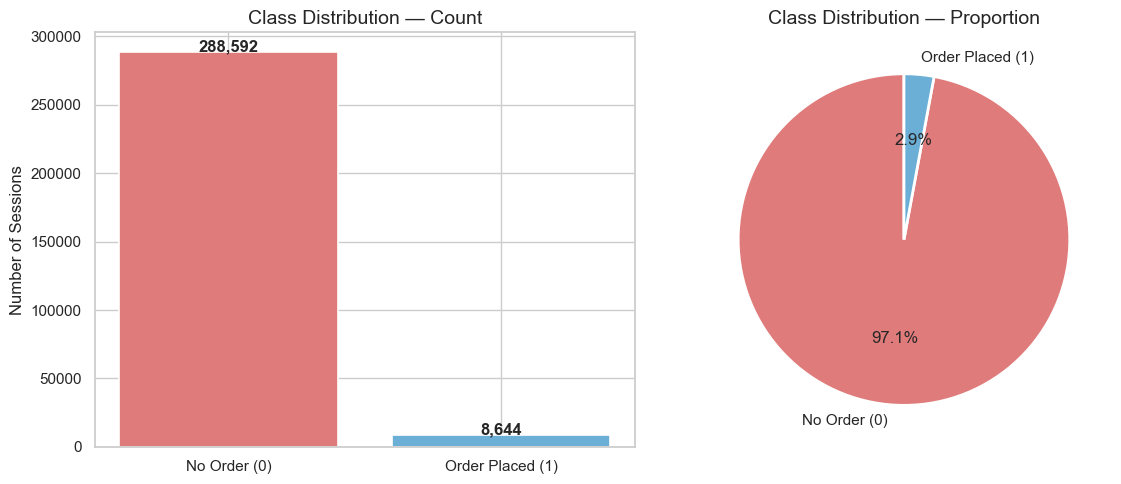

Saved: target_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['No Order (0)', 'Order Placed (1)'], target_counts.values,
            color=['#E07B7B', '#6BAED6'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution — Count')
axes[0].set_ylabel('Number of Sessions')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Order (0)', 'Order Placed (1)'],
            autopct='%1.1f%%', colors=['#E07B7B', '#6BAED6'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Proportion')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: target_distribution.png")


## 5. Missing Values

We check every column for nulls. Columns with missing values need to be dealt with at this stage.


In [11]:
def missing_summary(df, name="DataFrame"):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    summary = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct.round(2)
    })
    summary = summary[summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    
    if summary.empty:
        print(f"{name}: No missing values found!")
    else:
        print(f"{name}: {len(summary)} columns have missing values:")
        print(summary)
    return summary

train_missing = missing_summary(train, "Train")
print()
test_missing  = missing_summary(test,  "Test")


Train: 5 columns have missing values:
                    Missing Count  Missing %
promo_type                  90518      30.45
discount_value              90518      30.45
min_spend_required          90518      30.45
promos_shown                90518      30.45
promo_response              90518      30.45

Test: 5 columns have missing values:
                    Missing Count  Missing %
promo_type                  30004      30.11
discount_value              30004      30.11
min_spend_required          30004      30.11
promos_shown                30004      30.11
promo_response              30004      30.11


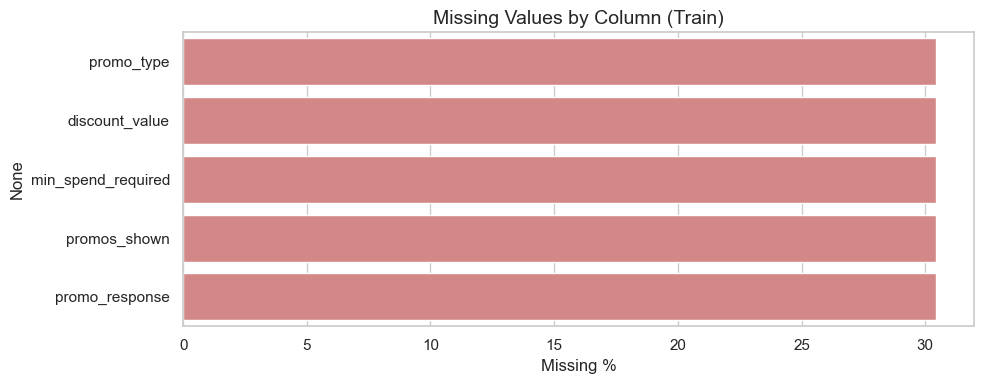

In [12]:
# Visualize missing values if any exist
if not train_missing.empty:
    plt.figure(figsize=(10, max(4, len(train_missing) * 0.5)))
    sns.barplot(x=train_missing['Missing %'], y=train_missing.index, color='#E07B7B')
    plt.xlabel('Missing %')
    plt.title('Missing Values by Column (Train)')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'missing_values.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No missing value chart needed.")


## 6. Categorical Feature Analysis

Categorical features: session_id, action_type, customer_type, promo_type, promo_response  
For each, we look at:
- How many unique values
- Value counts
- Order rate per category (what % of sessions in each category result in an order)


In [13]:
categorical_cols = ['action_type', 'customer_type', 'promo_type', 'promo_response']

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"Feature: {col}")
    print(f"Unique values: {train[col].nunique()}")
    print(train[col].value_counts())



Feature: action_type
Unique values: 2
action_type
PAGE_LOAD      290959
CART_CHANGE      6277
Name: count, dtype: int64

Feature: customer_type
Unique values: 2
customer_type
OC    170751
NC    126485
Name: count, dtype: int64

Feature: promo_type
Unique values: 4
promo_type
F    96264
C    56045
P    52531
S     1878
Name: count, dtype: int64

Feature: promo_response
Unique values: 3
promo_response
IGNORED     190845
DECLINED      8965
ACCEPTED      6908
Name: count, dtype: int64


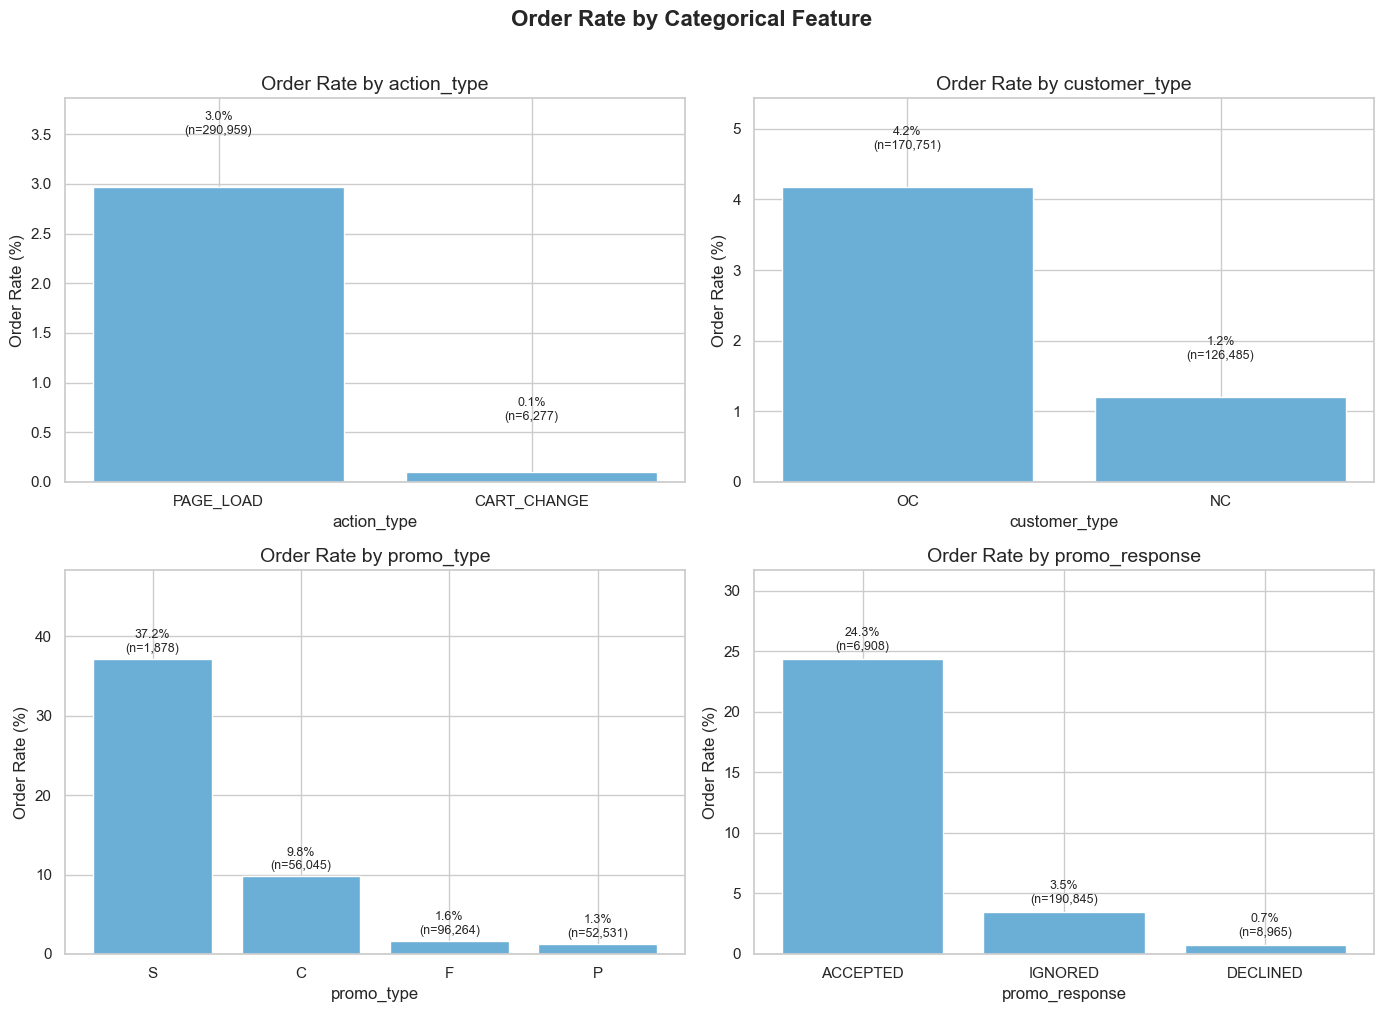

Saved: categorical_order_rates.png


In [14]:
# Order rate per category visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order_rate = train.groupby(col)['order_placed'].mean().sort_values(ascending=False)
    counts     = train[col].value_counts()
    
    bars = axes[i].bar(order_rate.index.astype(str), order_rate.values * 100,
                       color='#6BAED6', edgecolor='white')
    
    # Add count labels on bars
    for bar, (cat, rate) in zip(bars, order_rate.items()):
        count = counts.get(cat, 0)
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{rate*100:.1f}%\n(n={count:,})',
                     ha='center', va='bottom', fontsize=9)
    
    axes[i].set_title(f'Order Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Order Rate (%)')
    axes[i].set_ylim(0, min(100, order_rate.max() * 130))
    
    # Rotate x labels if many categories
    if train[col].nunique() > 4:
        axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Order Rate by Categorical Feature', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'categorical_order_rates.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: categorical_order_rates.png")


## 7. Numeric Feature Analysis

Numeric features: timezone, promos_declined, items_in_cart, cart_value, discount_value, min_spend_required, promos_shown, screen_size  
For each we look at:
- Distribution (histogram)
- Boxplot split by target (order placed vs not) to show separation


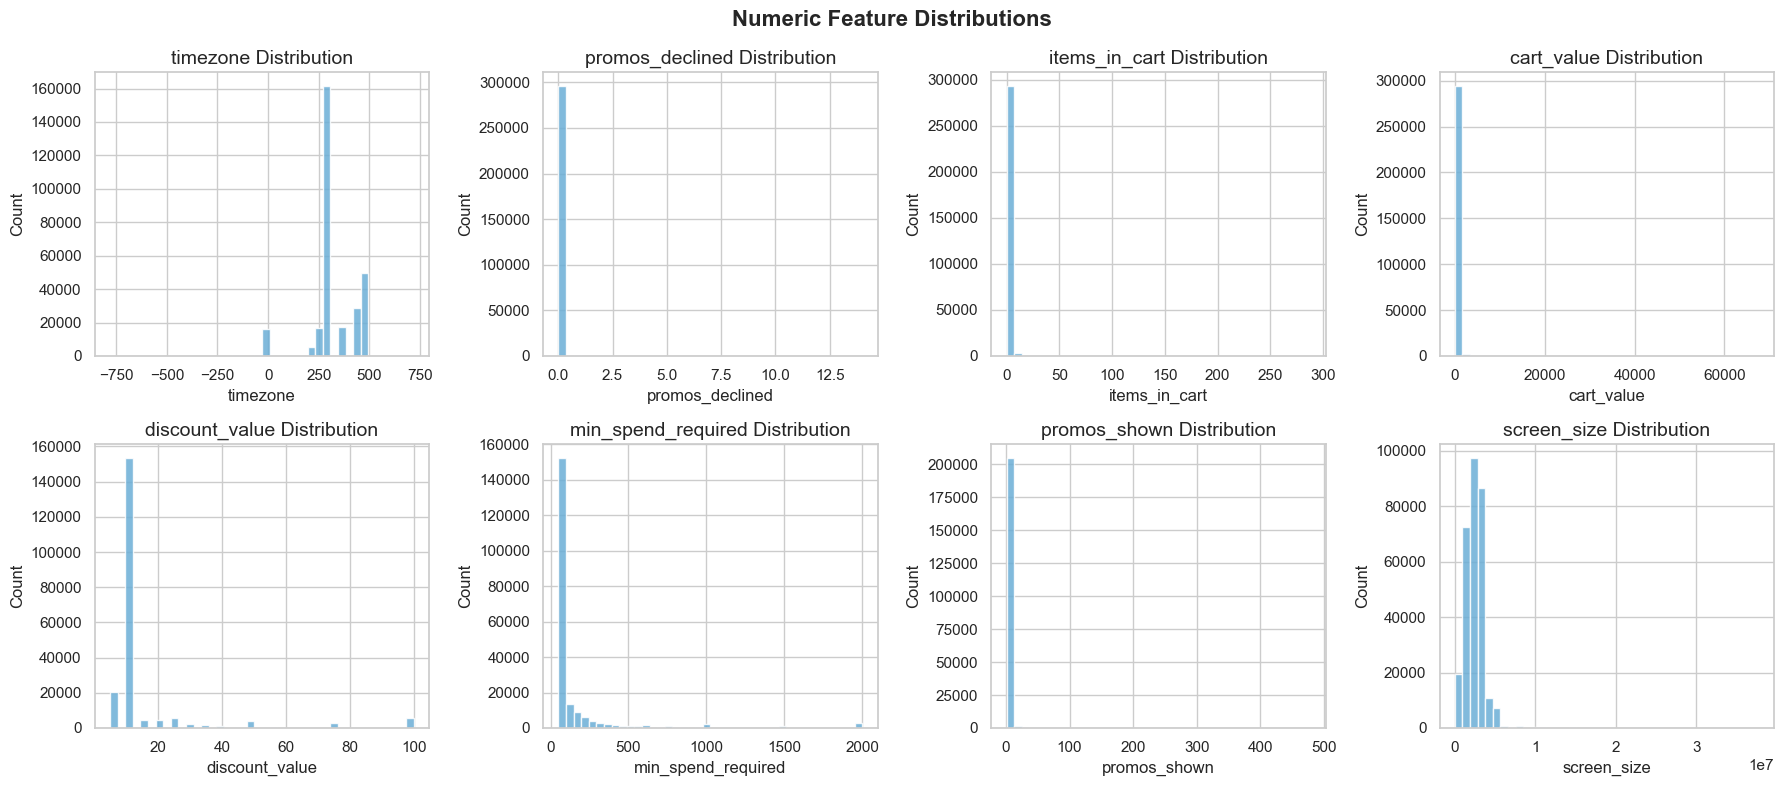

Saved: numeric_distributions.png


In [15]:
numeric_cols = ['timezone', 'promos_declined', 'items_in_cart', 'cart_value', 'discount_value', 'min_spend_required', 'promos_shown', 'screen_size']

# Distribution overview
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(train[col].dropna(), bins=40, color='#6BAED6', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'numeric_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: numeric_distributions.png")


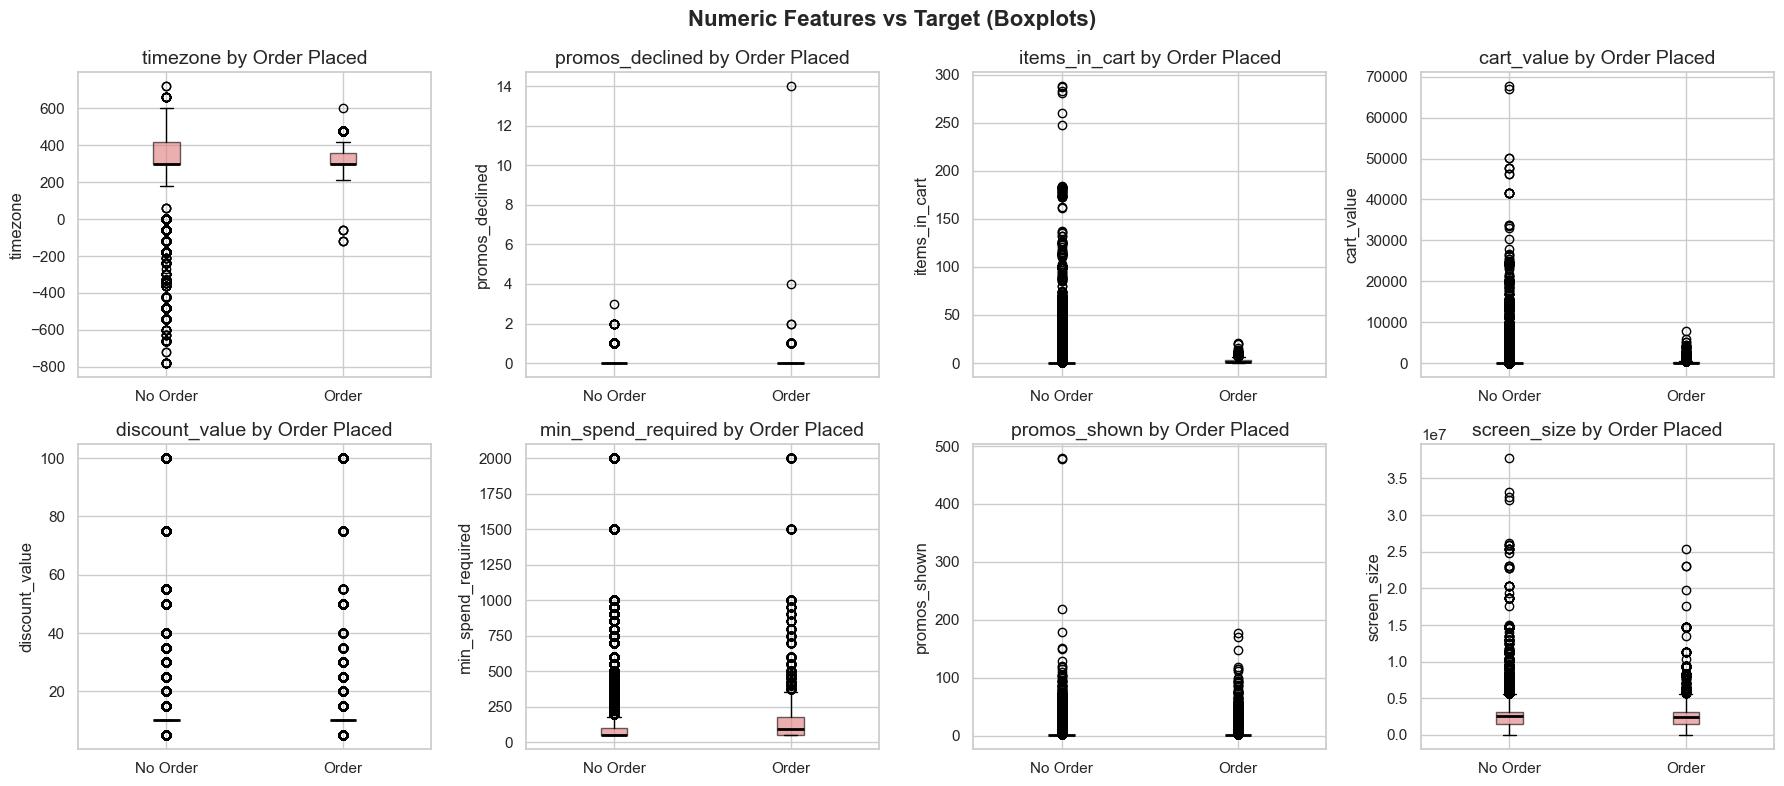

Saved: numeric_boxplots_by_target.png


In [16]:
# Boxplots split by target. In other words, shows if features separate orders vs non-orders
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data_0 = train[train['order_placed'] == 0][col].dropna()
    data_1 = train[train['order_placed'] == 1][col].dropna()
    
    axes[i].boxplot([data_0, data_1], labels=['No Order', 'Order'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#E07B7B', alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(f'{col} by Order Placed')
    axes[i].set_ylabel(col)

plt.suptitle('Numeric Features vs Target (Boxplots)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'numeric_boxplots_by_target.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: numeric_boxplots_by_target.png")


In [17]:
# Mean value of each numeric feature split by target
print("Mean values by target class:\n")
mean_by_target = train.groupby('order_placed')[numeric_cols].mean().T
mean_by_target.columns = ['No Order (0)', 'Order Placed (1)']
mean_by_target['Difference'] = mean_by_target['Order Placed (1)'] - mean_by_target['No Order (0)']
mean_by_target['Diff %'] = ((mean_by_target['Difference'] / mean_by_target['No Order (0)'].abs()) * 100).round(1)
print(mean_by_target.round(3))


Mean values by target class:

                    No Order (0)  Order Placed (1)  Difference  Diff %
timezone                 319.491           336.396      16.905     5.3
promos_declined            0.003             0.010       0.007   199.1
items_in_cart              0.746             2.100       1.354   181.6
cart_value                99.012           198.134      99.123   100.1
discount_value            15.106            15.428       0.322     2.1
min_spend_required       149.273           169.237      19.964    13.4
promos_shown               1.273             3.244       1.971   154.9
screen_size          2443364.982       2589349.012  145984.030     6.0


## 8. Timestamp Analysis

session_start = session start, session_end = session end, last_activity = last activity  
We parse these and derive:
- **Session duration** = session_end - session_start (how long the session lasted)
- **Inactivity gap** = session_end - last_activity (how long since the last action before session ended)
- **Hour of day** = from session_start (ordering patterns by time)
- **Day of week** = from session_start (ordering patterns by weekday)

These derived features will be used in feature engineering.


In [18]:
# Parse timestamps
for col in ['session_start', 'session_end', 'last_activity']:
    train[col] = pd.to_datetime(train[col], errors='coerce')
    test[col]  = pd.to_datetime(test[col],  errors='coerce')

# Derive duration features (in seconds)
train['session_duration_s'] = (train['session_end'] - train['session_start']).dt.total_seconds()
train['inactivity_gap_s']   = (train['session_end'] - train['last_activity']).dt.total_seconds()

# Time context features
train['hour_of_day']  = train['session_start'].dt.hour
train['day_of_week']  = train['session_start'].dt.dayofweek  # 0=Monday, 6=Sunday
train['is_weekend']   = (train['day_of_week'] >= 5).astype(int)

print("Timestamp features derived:")
print(train[['session_start','session_end','last_activity','session_duration_s','inactivity_gap_s','hour_of_day','day_of_week','is_weekend']].head())


Timestamp features derived:
                     session_start                      session_end  \
0 2017-03-07 00:17:41.049000+00:00 2017-03-07 00:47:41.049000+00:00   
1 2017-03-03 07:17:25.925000+00:00 2017-03-03 07:47:25.925000+00:00   
2 2017-03-06 14:31:23.833000+00:00 2017-03-06 15:01:23.833000+00:00   
3 2017-03-03 15:45:27.598000+00:00 2017-03-03 16:15:27.598000+00:00   
4 2017-03-05 10:39:37.622000+00:00 2017-03-05 11:09:37.622000+00:00   

                     last_activity  session_duration_s  inactivity_gap_s  \
0 2017-03-07 00:40:04.857000+00:00              1800.0           456.192   
1 2017-03-03 07:42:06.853000+00:00              1800.0           319.072   
2 2017-03-06 14:51:43.569000+00:00              1800.0           580.264   
3 2017-03-03 15:49:30.165000+00:00              1800.0          1557.433   
4 2017-03-05 11:07:28.130000+00:00              1800.0           129.492   

   hour_of_day  day_of_week  is_weekend  
0            0            1           0  
1   

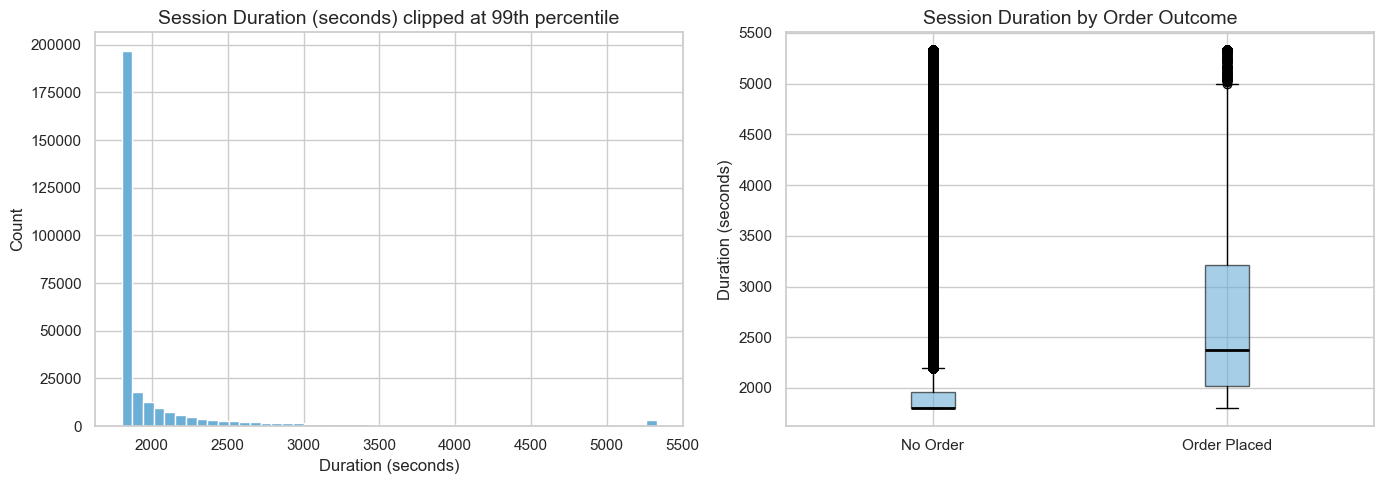

In [19]:
# Session duration distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clip outliers for cleaner visualization (99th percentile)
dur_clip = train['session_duration_s'].clip(upper=train['session_duration_s'].quantile(0.99))
axes[0].hist(dur_clip, bins=50, color='#6BAED6', edgecolor='white')
axes[0].set_title('Session Duration (seconds) clipped at 99th percentile')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')

# Duration by target
data_0 = train[train['order_placed']==0]['session_duration_s'].clip(upper=train['session_duration_s'].quantile(0.99))
data_1 = train[train['order_placed']==1]['session_duration_s'].clip(upper=train['session_duration_s'].quantile(0.99))
axes[1].boxplot([data_0, data_1], labels=['No Order', 'Order Placed'],
                patch_artist=True,
                boxprops=dict(facecolor='#6BAED6', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Session Duration by Order Outcome')
axes[1].set_ylabel('Duration (seconds)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'session_duration.png'), dpi=150, bbox_inches='tight')
plt.show()


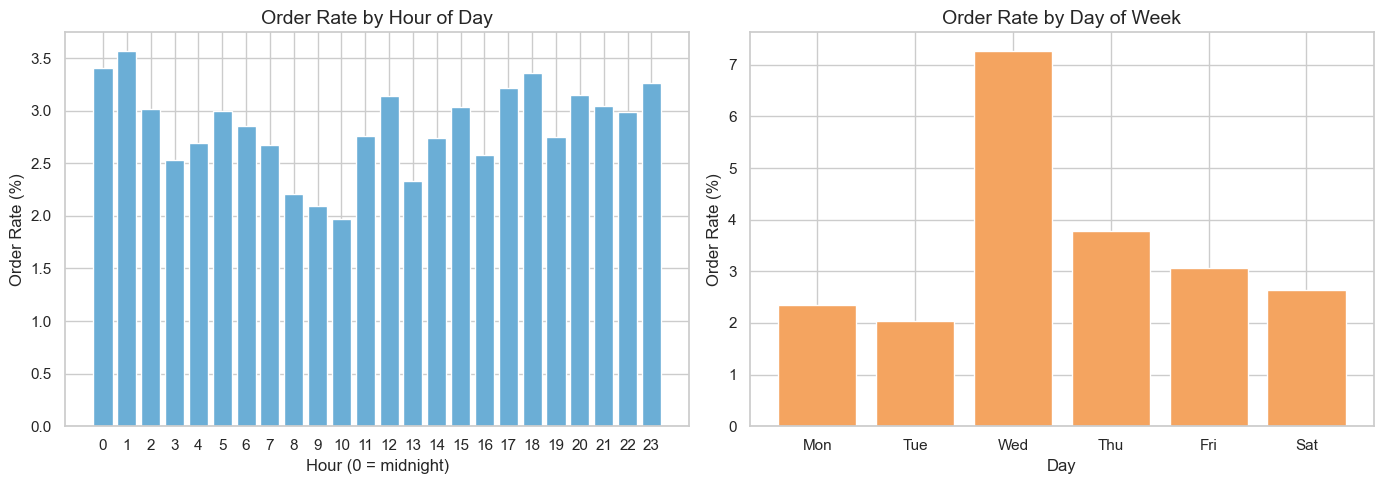

Saved: order_rate_by_time.png


In [20]:
# Order rate by hour of day
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_rate = train.groupby('hour_of_day')['order_placed'].mean() * 100
axes[0].bar(hour_rate.index, hour_rate.values, color='#6BAED6', edgecolor='white')
axes[0].set_title('Order Rate by Hour of Day')
axes[0].set_xlabel('Hour (0 = midnight)')
axes[0].set_ylabel('Order Rate (%)')
axes[0].set_xticks(range(0, 24))

# Order rate by day of week
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_rate = train.groupby('day_of_week')['order_placed'].mean() * 100
axes[1].bar(day_labels[:len(day_rate)], day_rate.values, color='#F4A460', edgecolor='white')
axes[1].set_title('Order Rate by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Order Rate (%)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'order_rate_by_time.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: order_rate_by_time.png")


## 9. Correlation Analysis

We compute the correlation of all numeric features with the target.  
Features with high absolute correlation are the most predictive at a basic level.  
Note: correlation only captures linear relationships — tree models can capture non-linear ones too.


In [21]:
# Select numeric columns + derived time features
num_features = numeric_cols + ['session_duration_s', 'inactivity_gap_s', 'hour_of_day', 'day_of_week', 'is_weekend']
corr_with_target = train[num_features + ['order_placed']].corr()['order_placed'].drop('order_placed')
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False)

print("Correlation with order_placed (sorted by absolute value):")
print(corr_with_target.round(4))


Correlation with order_placed (sorted by absolute value):
session_duration_s    0.1413
inactivity_gap_s      0.1249
promos_shown          0.1116
items_in_cart         0.0572
timezone              0.0238
cart_value            0.0228
screen_size           0.0183
promos_declined       0.0170
day_of_week           0.0165
min_spend_required    0.0135
discount_value        0.0036
is_weekend           -0.0028
hour_of_day           0.0015
Name: order_placed, dtype: float64


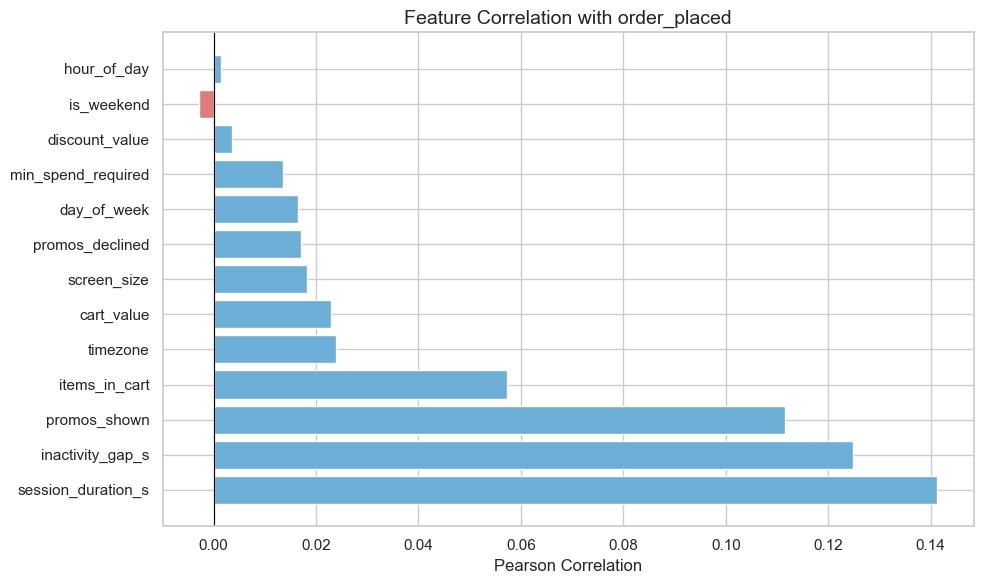

Saved: correlation_with_target.png


In [22]:
# Visualize correlations
plt.figure(figsize=(10, 6))
colors = ['#E07B7B' if v < 0 else '#6BAED6' for v in corr_with_target.values]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with order_placed')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_with_target.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_with_target.png")


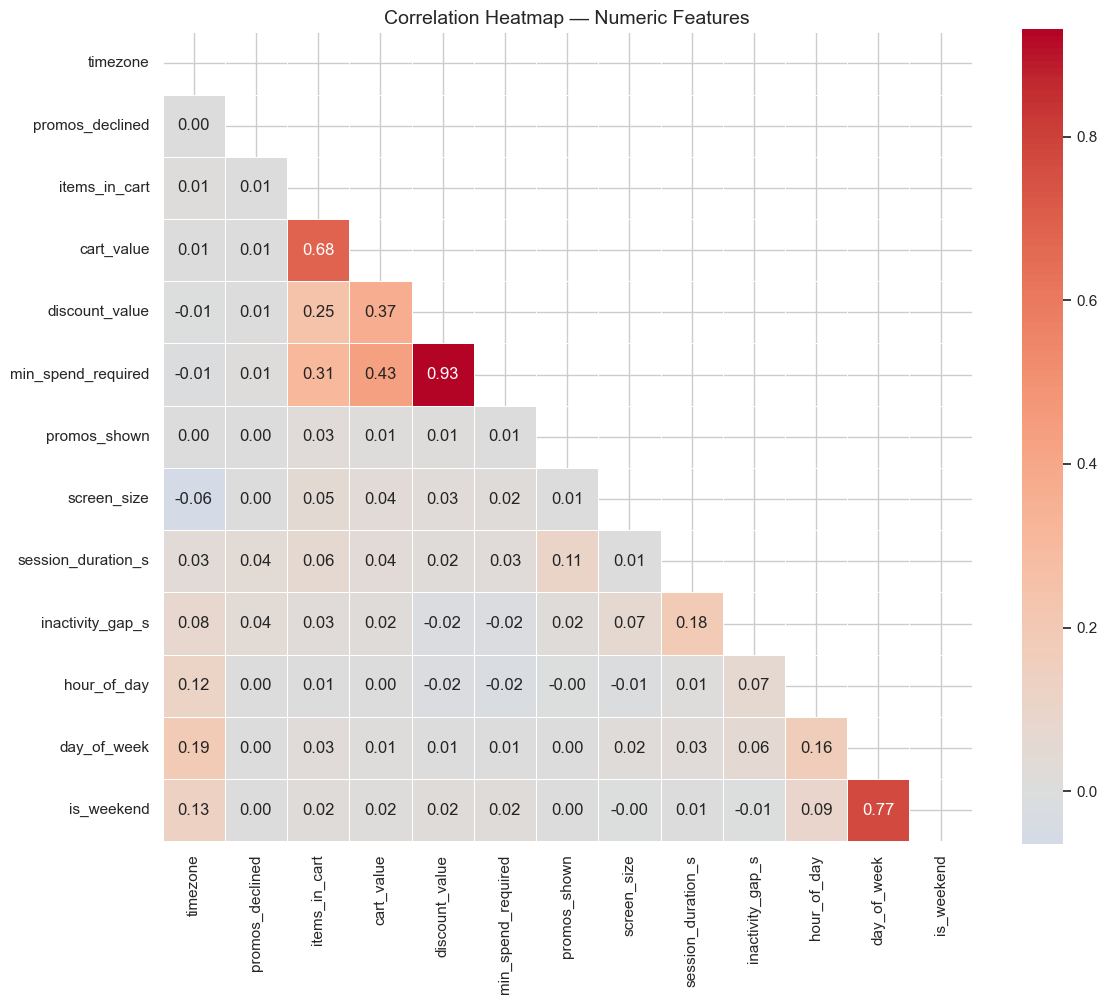

Saved: correlation_heatmap.png


In [23]:
# Full correlation heatmap between numeric features
plt.figure(figsize=(12, 10))
corr_matrix = train[num_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")


## 10. Key Insights Summary


In [24]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print(f"\nDataset size      : {len(train):,} sessions")
print(f"Number of features : {train.shape[1] - 1} (excluding target)")

order_rate = train['order_placed'].mean() * 100
print(f"\nOrder rate        : {order_rate:.1f}%  ({100-order_rate:.1f}% did NOT order)")
if order_rate < 30 or order_rate > 70:
    print("Class imbalance detected. Consider class_weight or resampling in modeling phase")
else:
    print("Classes are reasonably balanced")

print(f"\nMissing values    :", "None" if train_missing.empty else f"{len(train_missing)} columns affected")

print(f"\nTop correlated features with target:")
print(corr_with_target.head(5).to_string())

print("\nFeatures to engineer in Phase 3:")
print("  - session_duration_s (session_end - session_start)")
print("  - inactivity_gap_s   (session_end - last_activity)")
print("  - promo_gap          (cart_value - min_spend_required): how far cart value is from promo threshold")
print("  - cart_to_threshold  (cart_value / min_spend_required): ratio of cart value to required threshold")
print("  - hour_of_day, day_of_week, is_weekend")
print("  - Encode: action_type, customer_type, promo_type, promo_response")


EDA SUMMARY

Dataset size      : 297,236 sessions
Number of features : 22 (excluding target)

Order rate        : 2.9%  (97.1% did NOT order)
Class imbalance detected. Consider class_weight or resampling in modeling phase

Missing values    : 5 columns affected

Top correlated features with target:
session_duration_s    0.141269
inactivity_gap_s      0.124942
promos_shown          0.111628
items_in_cart         0.057248
timezone              0.023844

Features to engineer in Phase 3:
  - session_duration_s (session_end - session_start)
  - inactivity_gap_s   (session_end - last_activity)
  - promo_gap          (cart_value - min_spend_required): how far cart value is from promo threshold
  - cart_to_threshold  (cart_value / min_spend_required): ratio of cart value to required threshold
  - hour_of_day, day_of_week, is_weekend
  - Encode: action_type, customer_type, promo_type, promo_response


## 11. Save Data for Next Phase

We save the train data with the derived timestamp features added.  
Load `train_eda.csv` directly in the preprocessing notebook.


In [25]:
# Drop the raw timestamp columns. Keep derived features
train_save = train.copy()

save_path = os.path.join(DATA_DIR, 'train_eda.csv')
train_save.to_csv(save_path, index=False)
print(f"Saved: {save_path}")
print(f"Shape: {train_save.shape}")
print(f"Columns: {list(train_save.columns)}")


Saved: ..\data\train_eda.csv
Shape: (297236, 23)
Columns: ['id', 'session_id', 'session_start', 'session_end', 'last_activity', 'timezone', 'action_type', 'promos_declined', 'customer_type', 'items_in_cart', 'cart_value', 'promo_type', 'discount_value', 'min_spend_required', 'promos_shown', 'screen_size', 'promo_response', 'order_placed', 'session_duration_s', 'inactivity_gap_s', 'hour_of_day', 'day_of_week', 'is_weekend']
